# Star Observatory

Task author: Asandei Stefan-Alexandru

## Overview
Ground-based astronomy faces a fundamental challenge: the Earth's atmosphere. While space telescopes enjoy a pristine view of the cosmos, terrestrial observatories must contend with turbulent air masses that distort incoming light. This turbulence causes stars to twinkle, a phenomenon known as scintillation, and blurs celestial images, spreading the light of a point source over a larger area. This degradation limits the precision with which astronomers can measure the brightness of stars.

In this task, you act as a data scientist for the Star Observatory. We are conducting a survey to measure the intrinsic brightness (flux) of thousands of stars. However, our measurements are heavily affected by varying atmospheric conditions. The amount of atmosphere the light passes through (airmass) and the severity of atmospheric turbulence (seeing) change constantly throughout the night.

Your goal is to build a machine learning model that recovers the **calibrated target flux** of a star. You are provided with the captured image of the star and the meteorological metadata recorded at the moment of observation. You must learn the relationship between the atmospheric parameters, the distorted image, and the underlying flux of the star.

### Physics Background
To solve this task, you must understand how astronomers measure light and how the atmosphere affects those measurements.

**Flux and Magnitude**: In astronomy, the brightness of a star is described by its Flux ($ F $), which represents the energy received per unit area per unit time. Historically, brightness is often denoted by Magnitude ($ m $), which is a logarithmic scale. The relationship between Flux and Magnitude is defined as:

$$ m = -2.5 \log_{10}(F) + C $$

Where $ C $ is a zero-point constant. Conversely, if we know the magnitude, the flux is proportional to $ 10^{-0.4m} $.

**Atmospheric Parameters**: The state of the atmosphere is defined by two primary values in our dataset:
*   **Airmass ($ X $):** A measure of the amount of air the light passes through. If a star is directly overhead (zenith), $ X=1 $. As the star moves toward the horizon, $ X $ increases. More airmass generally means more light is absorbed or scattered (extinction).
*   **Fried Parameter ($ r_0 $):** This measures the quality of "seeing", or atmospheric turbulence. It represents the diameter of the telescope aperture over which the atmosphere is coherent. **Higher $ r_0 $ indicates calmer air and better images;** lower $ r_0 $ results in more blurring.

**Image Formation**: Ideally, a star is a point source. However, due to diffraction and atmospheric turbulence, the light is spread out into a blob called the Point Spread Function (PSF). The observed image $ I(x,y) $ can be modeled as the convolution of the true star flux $ S $ with the atmospheric PSF, plus background noise $ N $:

$$ I(x,y) = (S * \text{PSF}_{r_0, X})(x,y) + N $$

The shape and width of the PSF are highly dependent on $ r_0 $ and $ X $. Additionally, the sensor introduces Poisson (photon) noise and electronic readout noise.

In [462]:
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import numpy as np

import torch
import torchvision.transforms.v2 as v2
from torch.utils.data import Dataset, DataLoader

In [463]:
root_path = "./data" # dataset path
device = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

batch_size = 16

# Data

The dataset comprises 1,000 training images and 300 test images, each $ 128 \times 128 $ pixels. Every image contains precisely one star. The training data includes the true target flux values, while the test set requires prediction. The provided files are:
*   `train_images/00000.png` through `00999.png`: Training images
*   `train.csv`: Metadata including `image_id`, `fried_parameter`, `airmass` and `target_flux`
*   `test_images/00000.png` through `00299.png`: Test images
*   `test.csv`: Test metadata with `image_id` only

In [464]:
class AstralDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = f"{root_path}/train_images/{row['image_id']}"
        image = Image.open(img_path).convert("L")
        if self.transform:
            image = self.transform(image)

        if "target_flux" in row:
            target = row["target_flux"]
            return image, torch.tensor(target, dtype=torch.float32)

        return image

    def __len__(self):
        return len(self.df)

In [465]:
train_df = pd.read_csv(f"{root_path}/train.csv")
test_df = pd.read_csv(f"{root_path}/test.csv")
test_hidden = pd.read_csv(f"{root_path}/test_hidden.csv")
val = np.array((test_hidden["center_x"].to_numpy(), test_hidden["center_y"].to_numpy())).T

print(val)
train_df.head()

[[ 64.24988011  84.47666423]
 [ 27.97688762  81.6828552 ]
 [ 80.82060743  41.96266207]
 [ 54.32989437  32.86781581]
 [ 41.28012423  85.73397433]
 [ 72.77276459  84.29989649]
 [ 30.59890705  85.92552332]
 [ 55.44739786  68.16678633]
 [ 61.12723194  96.45209077]
 [ 75.17625287  26.1092505 ]
 [ 93.06218585  42.73534067]
 [ 32.62441574  97.34888465]
 [ 69.47521839  80.84475273]
 [ 35.01709159  40.76552989]
 [ 60.95770902 101.145458  ]
 [ 69.92558268  64.44196146]
 [ 98.53220164  37.61754505]
 [ 77.64825428  30.03565564]
 [ 31.56720257  40.45244714]
 [ 82.77682876  30.98325438]
 [ 38.18832212  60.91107701]
 [ 38.40260829  28.66472357]
 [ 37.87746161  81.8762619 ]
 [ 33.94893064  41.760601  ]]


,image_id,fried_parameter,airmass,target_flux
0,00000.png,1.320525,1.328511,3104.153567
1,00001.png,0.953145,1.279548,2574.724655
2,00002.png,0.661622,1.309472,2044.014880
3,00003.png,0.914006,1.790308,1971.258685
4,00004.png,1.539929,1.648373,3052.443416


In [466]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

train_ds = AstralDataset(train_df, transform)
test_ds = AstralDataset(test_df, transform)
val_ds = AstralDataset(val, transform)

train_loader = DataLoader(train_ds, batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size, shuffle=False)
val_loarder = DataLoader(val, batch_size, shuffle=False)

In [467]:
batch = next(iter(train_loader))
[b.shape for b in batch]

[torch.Size([16, 1, 128, 128]), torch.Size([16])]

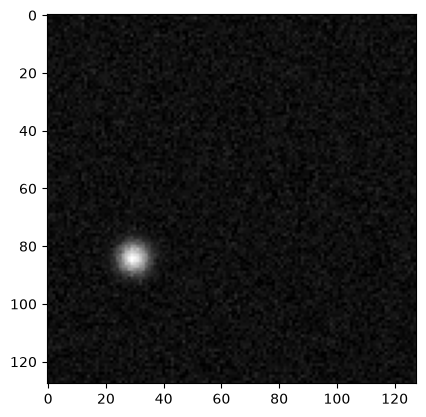

In [468]:
sample_idx = 0
sample_img = batch[0][sample_idx].permute(1, 2, 0)
plt.imshow(sample_img, cmap='gray')

# Subtask 1: Star Center Prediction (20 Points)
Each image contains one star, and you have to compute each center's coordinates within the image. The answer has to be in the format of a tuple with 2 elements.

In [469]:
# your code goes here
from sklearn.metrics import mean_absolute_error

subtask1 = []
max_indexes = []
for i in range(len(test_df)):
    id = test_df["image_id"][i]
    image = transform(Image.open(root_path + "\\test_images\\"+id).convert("L"))
    idx = image.argmax()
    cords = np.array(((idx%128), (idx//128)))
    subtask1.append(cords)
    max_indexes.append(idx)
    print(f"id:{id}\tcoords:{cords}")

# print(subtask1)


id:00000.png	coords:[64 84]
id:00001.png	coords:[29 82]
id:00002.png	coords:[80 42]
id:00003.png	coords:[54 32]
id:00004.png	coords:[41 86]
id:00005.png	coords:[72 83]
id:00006.png	coords:[31 85]
id:00007.png	coords:[54 67]
id:00008.png	coords:[60 96]
id:00009.png	coords:[75 26]
id:00010.png	coords:[92 43]
id:00011.png	coords:[32 97]
id:00012.png	coords:[70 80]
id:00013.png	coords:[35 41]
id:00014.png	coords:[ 60 100]
id:00015.png	coords:[69 64]
id:00016.png	coords:[98 37]
id:00017.png	coords:[77 30]
id:00018.png	coords:[31 40]
id:00019.png	coords:[82 30]
id:00020.png	coords:[37 60]
id:00021.png	coords:[39 28]
id:00022.png	coords:[37 82]
id:00023.png	coords:[34 41]


In [470]:
subtask1_arr = np.array(subtask1)
err = mean_absolute_error(subtask1_arr, val)
idx = val.argmax(axis=0)
# print("---")
# print(subtask1_arr)
# print("---")
print(err)

0.6193046101286659


tensor(174.5569)
tensor(0.0088)


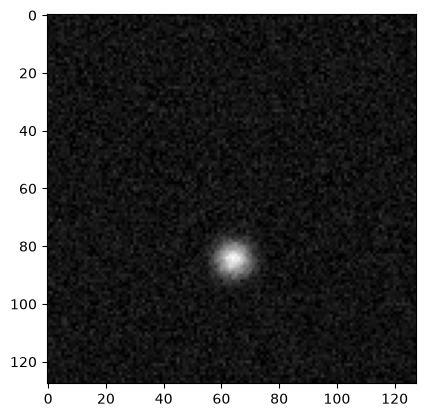

In [471]:
idx = 0
id = test_df["image_id"][idx]

image = transform(Image.open(root_path + "\\test_images\\"+id).convert("L"))
# image -= image.mean()
print(image.sum())
print(image.std())
# print(image[(0,subtask1_arr[0])].shape)
sample_img = image.permute(1, 2, 0)
plt.imshow(sample_img, cmap='gray')
plt.show()

In [472]:
subtask1 = [f"({float(x):.1f}, {float(y):.1f})" for x, y in subtask1]

# Subtask 2: Flux Prediction (80 Points)
Predict the `target_flux` (continuous value) of each star given its image and atmospheric parameters. The test set only has images.

In [473]:
def print_dir(obj):
    for i in dir(obj):
        if i.startswith("_"):
            continue
        print(i)

In [474]:
# your code goes here
from sklearn.model_selection import train_test_split
# from sklearn.tree import RandomForestRegressor
import sklearn
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.metrics import root_mean_squared_error
# print_dir(sklearn.ensemble)

image_ids = train_df["image_id"].to_numpy()
images = []
for id in image_ids:
    image = transform(Image.open(root_path + "/train_images/"+id).convert("L"))
    images.append(image)
images = np.array(images)
images = images.reshape(images.shape[0], -1)
print(images.shape, images.reshape(images.shape[0], -1).argmax(axis=1))
# X = np.vstack((train_df["fried_parameter"].to_numpy(), train_df["airmass"].to_numpy())).reshape(-1,2)
X = np.vstack((images.argmax(axis=1), images.mean(axis=1), images.max(axis=1))).T
y = train_df["target_flux"].to_numpy()
# print(y.mean(), y.std())
print(X.shape,y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

model = AdaBoostRegressor(learning_rate=1e-4)
# print_dir(model)
model.fit(X_train, y_train);
y_pred = model.predict(X_test)
diff = y_test - y_pred
# print(diff)
loss = root_mean_squared_error(y_test, y_pred)
print(loss)

(80, 16384) [ 7082  4390  7252 12602  9894  8373  9430  8138  5018  9315 13224 12449
  7763  5305  8526  6706  4512  3359 11459  4182  6332 10549  6300 10787
  7093 12884  8400  9645  4254 11982 12840  8794  6186  5563  9295 11066
  8022 11681 11805  3553 12389  7007  3992  9562  9048  9289  8652  3738
 10781 10411  8677 13262  9263 12896 10784 12384 12246  7718  9512 11612
 10981 10209 10587 13146  6631  8422  8366 11569  9949 12725 11096  5992
  8627  3392  7462  6358 11569  4445 10064 10970]
(80, 3) (80,)
125.20172088931639


In [475]:
image_ids = test_df["image_id"].to_numpy()
images = []
for id in image_ids:
    image = transform(Image.open(root_path + "/test_images/"+id).convert("L"))
    images.append(image)
images = np.array(images)
images = images.reshape(images.shape[0], -1)

X = np.vstack((images.argmax(axis=1), images.mean(axis=1), images.max(axis=1))).T
y = test_hidden["target_flux"].to_numpy()

subtask2 = model.predict(X)

loss = root_mean_squared_error(y, subtask2)
print(loss)
subtask2 = subtask2.tolist()

149.24565342995464


In [476]:
print(len(subtask1))
print(len(subtask2))

24
24


# Submission

In [477]:
def build_subtask(sid, answers):
    # print(sid)
    return pd.DataFrame({
        "subtaskID": sid,
        "datapointID": test_df["image_id"],
        "answer": answers
    })

subtasks = [
    (1, subtask1),
    (2, subtask2)
]

submission = pd.concat([build_subtask(sid, answers) for sid, answers in subtasks])
submission.head()

,subtaskID,datapointID,answer
0,1,00000.png,"(64.0, 84.0)"
1,1,00001.png,"(29.0, 82.0)"
2,1,00002.png,"(80.0, 42.0)"
3,1,00003.png,"(54.0, 32.0)"
4,1,00004.png,"(41.0, 86.0)"


## Evaluation & Scoring

**Total Score**
The final score is 100 points, the sum of the points obtained in each subtask.

In [478]:
submission.to_csv("sample_submission.csv", index=False)

Submit a single CSV containing exactly 600 samples. Example preview:

```text
subtaskID,datapointID,answer
1,00001.png,"(0.0, 0.0)"
1,00002.png,"(0.0, 0.0)"
2,00001.png,100.0
2,00002.png,100.0
...
```

## Constraints
*   At most 45 minutes of notebook run time (training + inference) on a free 16gb GPU (T4 on Google Colab or P100 on Kaggle).
*   No usage of LLMs for code writing or for submission generation.
*   No pre-trained models (ResNet, ViT, etc.)
*   It is forbidden to use any other data that is not included in the provided dataset.